In [36]:
%load_ext autoreload
%autoreload 2

import data_formater69 as df
import calib69 as calib
var_liste = ['M_D', 'M_F', 'Y', 'C', 'G', 'X', 'I', 'P', 'L', 'w', 'K', 'P_I', 'P_F', 'P_D', 'P_T','tau_MF', 'afgift','M_D_loebende']

#removing first year (1966) in L for all sectors
df.L = df.L.loc[df.L.index.get_level_values('TID') >= 1967]
df.w = df.w.loc[df.w.index.get_level_values('TID') >= 1967]
df.K = df.K.loc[df.K.index.get_level_values('TID') >= 1967]
df.K = df.K.loc[df.K.index.get_level_values('TID') <= 2022]
df.P_I = df.P_I.loc[df.P_I.index.get_level_values('TID') <= 2022]
#data for told findes først fra 2004

# Dimentions check
for var_navn in var_liste:
    obj = getattr(df, var_navn)
    print(f"{var_navn:4} -> Dimensioner: {obj.shape}")

# Eksempel: Se import af landbrugsvarer (j) til mejerier (i) over tid (t)
import_landbrug_til_mejerier = df.M_F.loc['10120', '01000', slice(None)]
import_landbrug_til_mejerier
df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
M_D  -> Dimensioner: (504, 1)
M_F  -> Dimensioner: (504, 1)
Y    -> Dimensioner: (168, 1)
C    -> Dimensioner: (168, 1)
G    -> Dimensioner: (168, 1)
X    -> Dimensioner: (168, 1)
I    -> Dimensioner: (90, 1)
P    -> Dimensioner: (168, 1)
L    -> Dimensioner: (168, 1)
w    -> Dimensioner: (168, 1)
K    -> Dimensioner: (168, 1)
P_I  -> Dimensioner: (93, 1)
P_F  -> Dimensioner: (504, 1)
P_D  -> Dimensioner: (504, 1)
P_T  -> Dimensioner: (171, 1)
tau_MF -> Dimensioner: (504, 1)
afgift -> Dimensioner: (171, 1)
M_D_loebende -> Dimensioner: (513, 1)


<module 'data_formater69' from 'p:\\carhed\\LF27\\LandbrugHistorieKalibrering\\Data\\Indlæsning af data\\data_formater69.py'>

### Afskrivningsrate
$$\delta_{it} =\frac{K_{i,t-1}-K_{it}+I_{it}}{K_{i,t-1}}$$

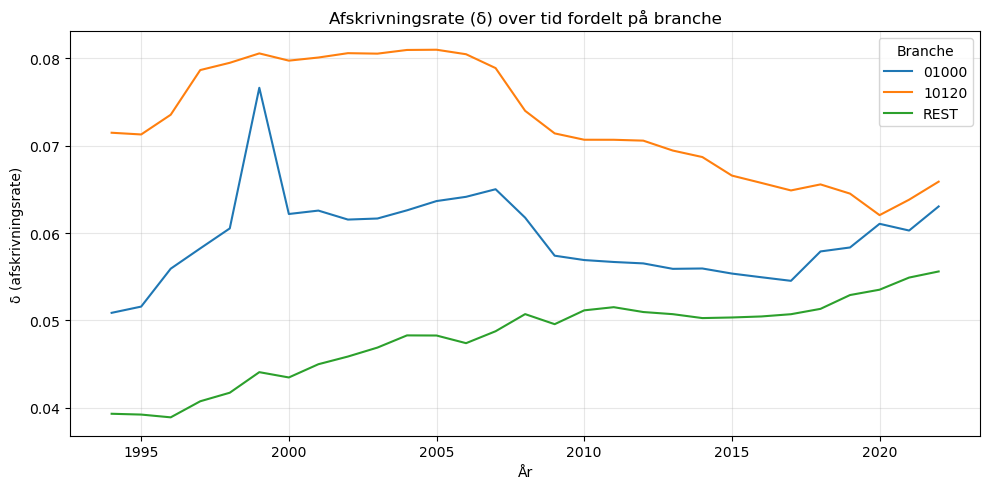

In [3]:
import matplotlib.pyplot as plt
# Kun 1993 og frem
d = calib.delta.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

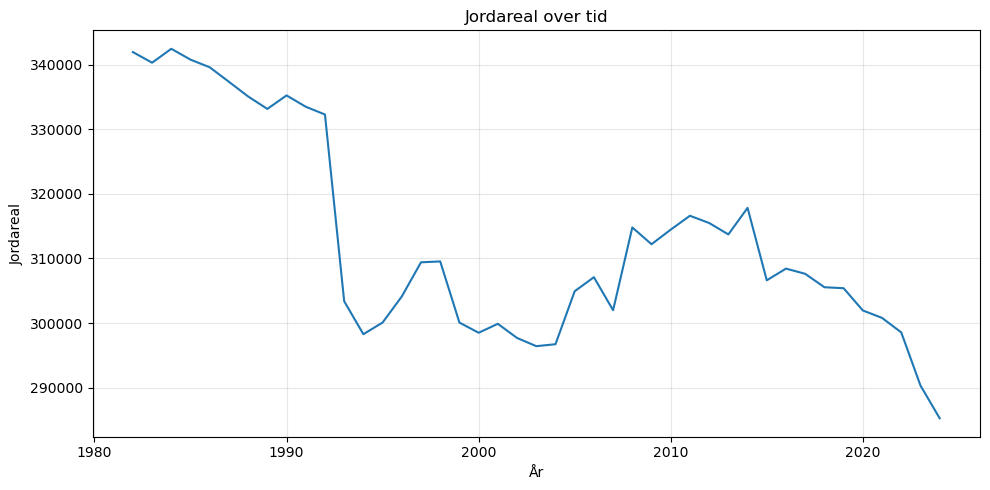

In [4]:
# Kun 1993 og frem
d = df.J
p =df.P_Jord
# Gør den "wide": år som index, branche som kolonner
# d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d['Xt'], label='Jordareal')
# plt.plot(p.index, p['Pt'], label='Jordpris')
plt.xlabel("År")
plt.ylabel("Jordareal")
plt.title("Jordareal over tid")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

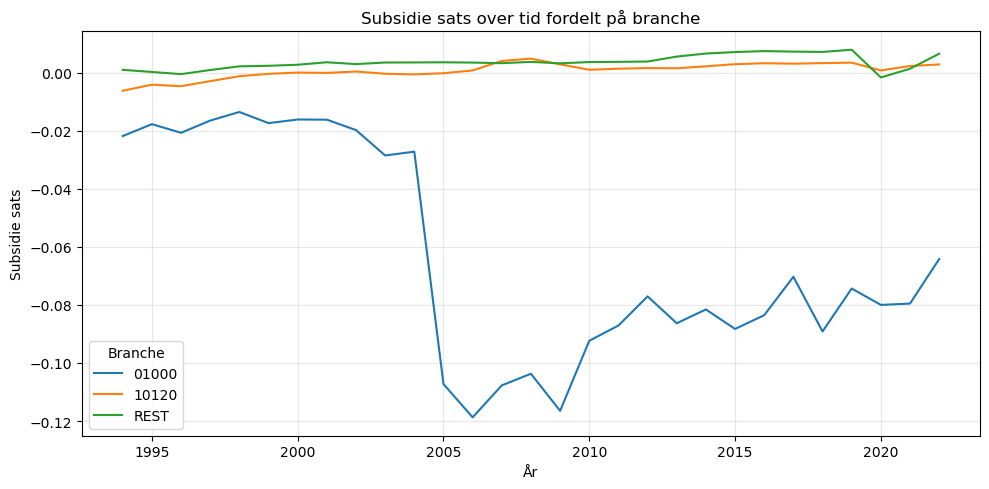

In [5]:
calib.tau_Y
# Kun 1993 og frem
d = calib.tau_Y.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Subsidie sats")
plt.title("Subsidie sats over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

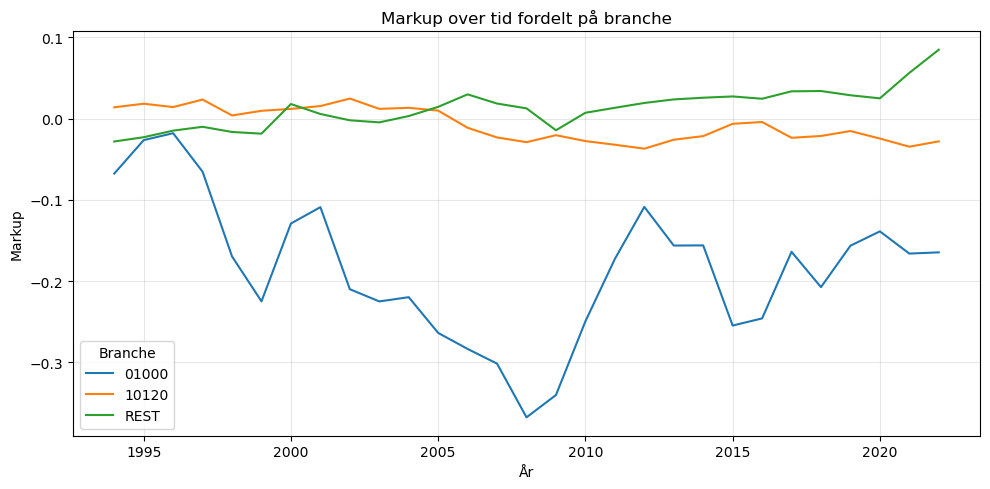

In [6]:

calib.markup

# Kun 1993 og frem
d = calib.markup.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()